This notebook analyzes uninsured rates in the United States using
American Community Survey (ACS) data, focusing on income level and gender.

In [2]:
#  How does the uninsured rate vary across income levels in the United States?
#  a. At what income level is the uninsured rate highest?
#  b. Are there clear affordability gaps?

# Filtering income rows
# Using percent_uninsured_estimate
# Sorting and comparing income groups

In [3]:
import pandas as pd   
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns
from datetime import datetime

In [4]:
Insurance_Coverage = pd.read_csv('../data/Selected Characteristics of Health Insurance Coverage in the United States.csv')

Uninsured Rate by Income

In [6]:
Insurance_Coverage.head()

,Label (Grouping),United States!!Total!!Estimate,United States!!Total!!Margin of Error,United States!!Insured!!Estimate,United States!!Insured!!Margin of Error,United States!!Percent Insured!!Estimate,United States!!Percent Insured!!Margin of Error,United States!!Uninsured!!Estimate,United States!!Uninsured!!Margin of Error,United States!!Percent Uninsured!!Estimate,United States!!Percent Uninsured!!Margin of Error
0,Civilian noninstitutionalized population,"335,190,522","±20,943","307,711,269","±220,757",91.8%,±0.1,"27,479,253","±218,734",8.2%,±0.1
1,AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Under 6 years,"22,112,429","±43,209","20,935,240","±49,737",94.7%,±0.1,"1,177,189","±28,298",5.3%,±0.1
3,6 to 18 years,"55,318,609","±65,587","51,847,380","±71,167",93.7%,±0.1,"3,471,229","±52,063",6.3%,±0.1
4,19 to 25 years,"30,393,815","±68,525","26,141,656","±71,188",86.0%,±0.2,"4,252,159","±50,873",14.0%,±0.2


In [7]:
Insurance_Coverage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype 
---  ------                                             --------------  ----- 
 0   Label (Grouping)                                   72 non-null     object
 1   United States!!Total!!Estimate                     61 non-null     object
 2   United States!!Total!!Margin of Error              61 non-null     object
 3   United States!!Insured!!Estimate                   61 non-null     object
 4   United States!!Insured!!Margin of Error            61 non-null     object
 5   United States!!Percent Insured!!Estimate           61 non-null     object
 6   United States!!Percent Insured!!Margin of Error    61 non-null     object
 7   United States!!Uninsured!!Estimate                 61 non-null     object
 8   United States!!Uninsured!!Margin of Error          61 non-null     object
 9   United States!!Percent 

In [8]:
Insur_Cover = Insurance_Coverage.rename(columns={'Label (Grouping)': 'label',
                                                        'United States!!Total!!Estimate': 'total_estimate',
                                                        'United States!!Total!!Margin of Error': 'total_margin',
                                                        'United States!!Insured!!Estimate': 'insured_estimate',
                                                        'United States!!Insured!!Margin of Error': 'insured_margin',
                                                        'United States!!Percent Insured!!Estimate': 'percent_insured_estimate',
                                                        'United States!!Percent Insured!!Margin of Error': 'percent_insured_margin',
                                                        'United States!!Uninsured!!Estimate': 'uninsured_estimate',
                                                        'United States!!Uninsured!!Margin of Error': 'uninsured_margin',
                                                        'United States!!Percent Uninsured!!Estimate': 'percent_ninsured_estimate',
                                                        'United States!!Percent Uninsured!!Margin of Error': 'percent_uninsured_margin'})
Insur_Cover.head()

,label,total_estimate,total_margin,insured_estimate,insured_margin,percent_insured_estimate,percent_insured_margin,uninsured_estimate,uninsured_margin,percent_ninsured_estimate,percent_uninsured_margin
0,Civilian noninstitutionalized population,"335,190,522","±20,943","307,711,269","±220,757",91.8%,±0.1,"27,479,253","±218,734",8.2%,±0.1
1,AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Under 6 years,"22,112,429","±43,209","20,935,240","±49,737",94.7%,±0.1,"1,177,189","±28,298",5.3%,±0.1
3,6 to 18 years,"55,318,609","±65,587","51,847,380","±71,167",93.7%,±0.1,"3,471,229","±52,063",6.3%,±0.1
4,19 to 25 years,"30,393,815","±68,525","26,141,656","±71,188",86.0%,±0.2,"4,252,159","±50,873",14.0%,±0.2


In [9]:
cols_to_convert = Insur_Cover.columns.drop('label')

for col in cols_to_convert:
    Insur_Cover[col] = (Insur_Cover[col].str.replace(",", "", regex=False).str.replace("%", "", regex=False))
    Insur_Cover[col] = pd.to_numeric(Insur_Cover[col], errors='coerce')
    
Insur_Cover.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   label                      72 non-null     object 
 1   total_estimate             61 non-null     float64
 2   total_margin               0 non-null      float64
 3   insured_estimate           61 non-null     float64
 4   insured_margin             0 non-null      float64
 5   percent_insured_estimate   61 non-null     float64
 6   percent_insured_margin     0 non-null      float64
 7   uninsured_estimate         61 non-null     float64
 8   uninsured_margin           0 non-null      float64
 9   percent_ninsured_estimate  61 non-null     float64
 10  percent_uninsured_margin   0 non-null      float64
dtypes: float64(10), object(1)
memory usage: 6.3+ KB


In [10]:
Insur_Cover = Insur_Cover[['label', 'total_estimate', 'insured_estimate', 'uninsured_estimate', 'percent_ninsured_estimate']]
Insur_Cover.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   label                      72 non-null     object 
 1   total_estimate             61 non-null     float64
 2   insured_estimate           61 non-null     float64
 3   uninsured_estimate         61 non-null     float64
 4   percent_ninsured_estimate  61 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.9+ KB


In [11]:
Insur_Cover = Insur_Cover[Insur_Cover['total_estimate'].notna()]
Insur_Cover.head()

,label,total_estimate,insured_estimate,uninsured_estimate,percent_ninsured_estimate
0,Civilian noninstitutionalized population,335190522.0,307711269.0,27479253.0,8.2
2,Under 6 years,22112429.0,20935240.0,1177189.0,5.3
3,6 to 18 years,55318609.0,51847380.0,3471229.0,6.3
4,19 to 25 years,30393815.0,26141656.0,4252159.0,14.0
5,26 to 34 years,40840056.0,35075671.0,5764385.0,14.1


In [12]:
Insur_Cover[['label', 'percent_ninsured_estimate']]

,label,percent_ninsured_estimate
0,Civilian noninstitutionalized population,8.2
2,Under 6 years,5.3
3,6 to 18 years,6.3
4,19 to 25 years,14.0
5,26 to 34 years,14.1
...,...,...
67,Civilian noninstitutionalized populati...,8.2
68,Below 138 percent of the poverty t...,14.0
69,138 to 399 percent of the poverty ...,10.5
70,At or above 400 percent of the pov...,3.8


In [13]:
Insur_Cover.sort_values('percent_ninsured_estimate', ascending=False).head(10)

,label,total_estimate,insured_estimate,uninsured_estimate,percent_ninsured_estimate
38,Not a citizen,24228426.0,17151725.0,7076701.0,29.2
52,Unemployed,7019739.0,5315630.0,1704109.0,24.3
44,Less than high school graduate,22692233.0,18020643.0,4671590.0,20.6
23,Some other race alone,25029477.0,20188899.0,4840578.0,19.3
20,American Indian and Alaska Native alone,3358041.0,2722130.0,635911.0,18.9
36,Foreign born,49871014.0,41036753.0,8834261.0,17.7
25,Hispanic or Latino (of any race),67234401.0,55777874.0,11456527.0,17.0
31,"Male reference person, no spou...",21855842.0,18445760.0,3410082.0,15.6
58,Did not work,36066377.0,30760676.0,5305701.0,14.7
57,"Worked less than full-time, year r...",46996571.0,40078382.0,6918189.0,14.7


In [14]:
Insur_Cover_Income = Insur_Cover[Insur_Cover["label"].isin(["            Under $25,000", "            $25,000 to $49,999", "            $50,000 to $74,999", "            $75,000 to $99,999", "            $100,000 and over"])]

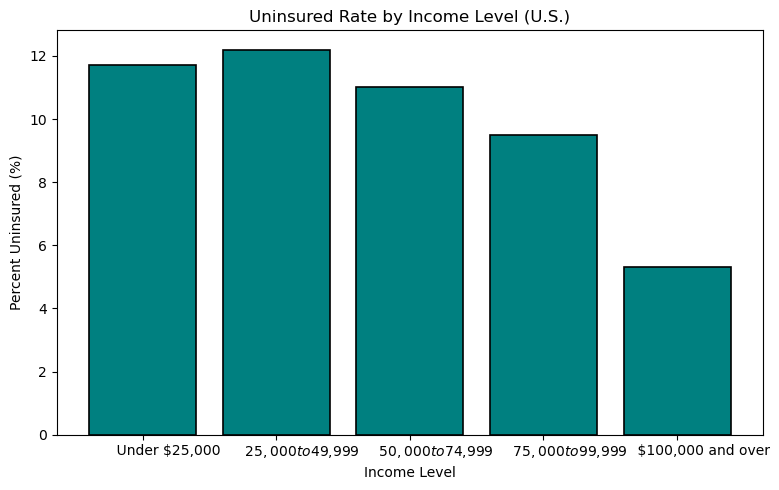

In [15]:
plt.figure(figsize=(8,5))
bars = plt.bar(Insur_Cover_Income['label'], Insur_Cover_Income['percent_ninsured_estimate'], color="teal", edgecolor="black", linewidth=1.2)
plt.ylabel("Percent Uninsured (%)")
plt.xlabel("Income Level")
plt.title("Uninsured Rate by Income Level (U.S.)")
plt.tight_layout()
plt.show()

Uninsured rates are highest among the lowest income groups and decrease steadily as income increases. This pattern suggests strong affordability barriers to health insurance coverage for lower-income households, even within the ACA marketplace.

In [17]:
df_gender = pd.read_csv('../data/Health Insurance Coverage Status by Sex.csv')

In [18]:
# Are there gender differences in uninsured rates?
#    a. Is one gender more likely to be uninsured?
#    b. How large is the difference?
#Calculate uninsured percentage by gender (or use provided percentages)

In [19]:
df_gender.head()

,gender,age,status,estimate,error
0,male,under6,insured,10687629,40625
1,male,under6,uninsured,598807,17235
2,male,6to18,insured,26520249,49688
3,male,6to18,uninsured,1807428,31512
4,male,19to25,insured,12951048,48898


In [20]:
df_gender.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   gender    36 non-null     object
 1   age       36 non-null     object
 2   status    36 non-null     object
 3   estimate  36 non-null     int64 
 4   error     36 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 1.5+ KB


In [21]:
df_gender_insured = df_gender[df_gender['status'] == "uninsured"]
df_gender_table = df_gender_insured[['gender', 'estimate']].groupby('gender').sum().reset_index()
df_gender_table

,gender,estimate
0,female,12311005
1,male,15168248


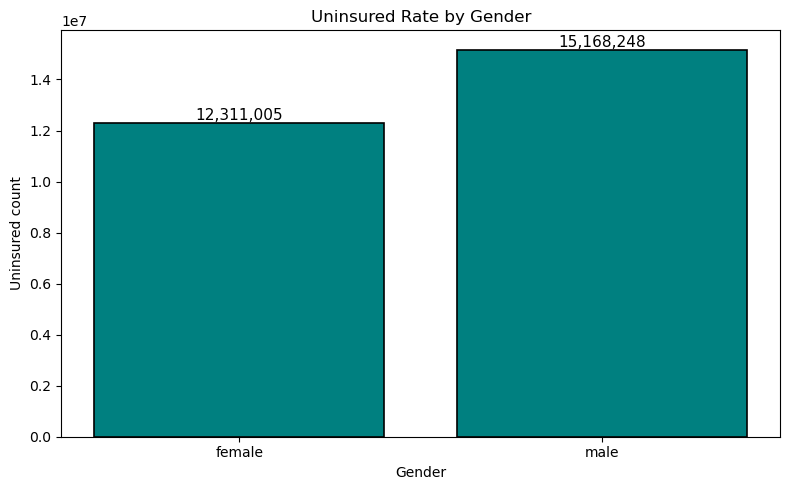

In [22]:
plt.figure(figsize=(8,5))
bars = plt.bar(df_gender_table['gender'], df_gender_table['estimate'], color="teal", edgecolor="black", linewidth=1.2)
plt.ylabel("Uninsured count")
plt.xlabel("Gender")
plt.title("Uninsured Rate by Gender")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.0,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11)
plt.tight_layout()
plt.show()

Uninsured rates are higher among men than women. While the difference is smaller than income-based disparities, it suggests demographic differences in insurance access or enrollment behavior.

In [24]:
df_gender_table["estimate"].diff()

0          NaN
1    2857243.0
Name: estimate, dtype: float64

In [25]:
df_age_gender_insured = df_gender[df_gender["status"] == "uninsured"]
df_age_gender_table = df_gender_insured[["gender", "age", "estimate"]].groupby(["gender", "age"]).sum().reset_index()

In [26]:
age_order = [
    "under6",
    "6to18",
    "19to25",
    "26to34",
    "35to44",
    "45to54",
    "55to64",
    "65to74",
    "75above"]

In [27]:
df_age_gender_table['age'] = pd.Categorical(df_age_gender_table['age'], categories=age_order, ordered=True)
df_age_gender_table = df_age_gender_table.sort_values('age')

In [28]:
df_age_gender_table

,gender,age,estimate
8,female,under6,578382
17,male,under6,598807
6,female,6to18,1663801
15,male,6to18,1807428
9,male,19to25,2379888
0,female,19to25,1872271
10,male,26to34,3353027
1,female,26to34,2411358
2,female,35to44,2248259
11,male,35to44,3022347


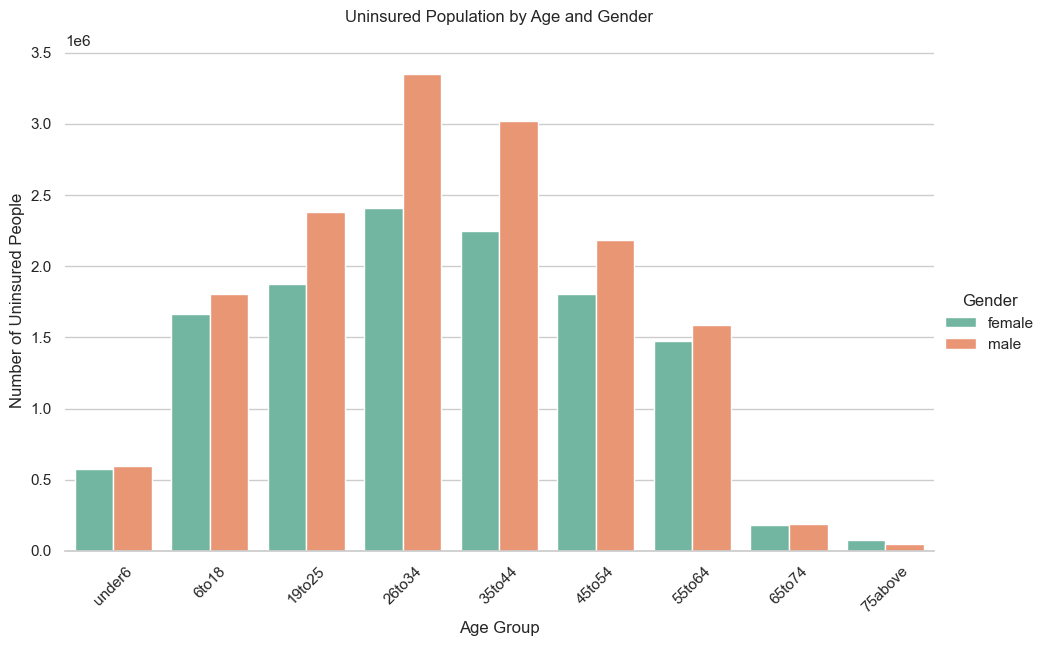

In [29]:
sns.set_theme(style='whitegrid')

g = sns.catplot(
    data=df_age_gender_table,
    kind="bar",
    x="age",
    y="estimate",
    hue="gender",
    palette="Set2",
    height=6,
    aspect=1.6)

g.set_axis_labels('Age Group', 'Number of Uninsured People')
g.legend.set_title('Gender')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

g.despine(left=True)
plt.title('Uninsured Population by Age and Gender', pad=20)
plt.show()